# Theory: Perceptron 

###  The Machine Learning Objective: Binary Linear Classification

The single‑layer perceptron is a supervised learning algorithm engineered to solve **binary classification** problems. Given an input feature vector space, the fundamental objective is to construct a decision boundary that cleanly maps feature coordinates to one of two discrete, mutually exclusive classes.

#### Formal Dataset Representation

Let a training dataset $\mathcal{D}$ consist of $M$ independent and identically distributed (i.i.d.) samples:

$$
\mathcal{D} = \{(\mathbf{x}^{(1)}, y^{(1)}), (\mathbf{x}^{(2)}, y^{(2)}), \dots, (\mathbf{x}^{(M)}, y^{(M)})\}
$$

Where:

- $\mathbf{x}^{(i)} \in \mathbb{R}^N$ – an $N$‑dimensional feature vector containing numerical attributes.
- $y^{(i)} \in \{-1, +1\}$ – the discrete categorical target using the symmetric binary label standard.

---

### The Geometric Axiom: Linear Separability

The perceptron depends entirely on a structural geometric condition known as **linear separability**.

#### Mathematical Definition

A binary dataset $\mathcal{D}$ is **strictly linearly separable** iff there exists an $(N-1)$‑dimensional hyperplane in $\mathbb{R}^N$ that partitions the input space into two infinite half‑spaces, cleanly separating positive from negative instances.

Formally, there must exist a weight vector $\mathbf{w}^* \in \mathbb{R}^N$ and a scalar bias $b^* \in \mathbb{R}$ such that:

$$
y^{(i)} \bigl(\mathbf{w}^{*T}\mathbf{x}^{(i)} + b^*\bigr) > 0 \quad \forall \, i \in \{1, \dots, M\}
$$

Equivalently:

$$
\begin{cases}
\mathbf{w}^{*T}\mathbf{x}^{(i)} + b^* \geq 0 & \text{if } y^{(i)} = +1 \\[4pt]
\mathbf{w}^{*T}\mathbf{x}^{(i)} + b^* < 0  & \text{if } y^{(i)} = -1
\end{cases}
$$

#### Dimensional Topology of the Boundary

- $N = 1$ (single feature) → decision boundary is a **point** on a line.
- $N = 2$ (two features) → boundary is a **straight line** in a plane.
- $N = 3$ (three features) → boundary is a **flat plane** in 3D space.
- $N > 3$ → boundary is a **hyperplane** in an abstract high‑dimensional space.



In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# ====================================================
# Module 1: SYNTHETIC DATA GENERATION & VISUALIZATION 
# ===================================================

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X,y = make_classification(n_samples=1000, n_features=2, n_informative=2, 
                          n_redundant=0, n_clusters_per_class=1, random_state=66, flip_y=0.01) #2->better than sklearn  #flip_y --- adds noise in data

# Mapping the classes
y = np.where(y==0, -1, y)

# splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45)

print(f"Dimension of Training set :{X_train.shape} | Test set : {X_test.shape}")

Dimension of Training set :(800, 2) | Test set : (200, 2)


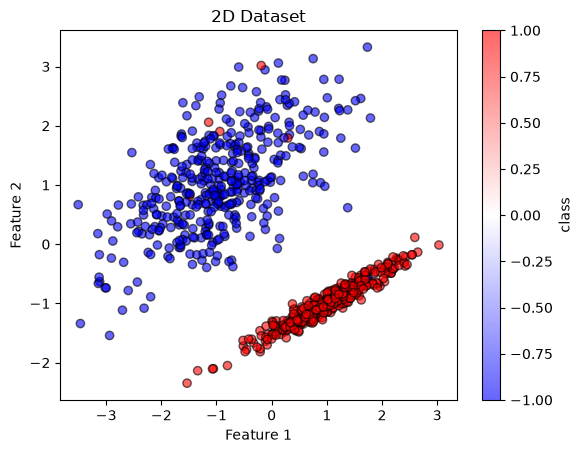

In [32]:
# ==================================
# Module 2: DATA VISUALIZATION
# ==================================

# 2D Plotting function
def twoD_plot_dataset(X, y):
    plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolors='k', alpha=0.6)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('2D Dataset')
    plt.colorbar(label='class')
    plt.show()  
    
# 3D Plotting function    
def threeD_plot_dataset(X, y):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X[:,0], X[:,1], X[:,2], c=y, cmap='bwr', edgecolors='k', alpha=0.6)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_zlabel('Feature 3')
    ax.set_title('3D Dataset')
    plt.show()

# plotting the features based on the number of features in the dataset
if X_train.shape[1] == 2:
    twoD_plot_dataset(X_train, y_train)
    
if X_train.shape[1] == 3:
    threeD_plot_dataset(X_train, y_train)

if X_test.shape[1] >3:
    print("The dataset has more than 3 features. Use dimensionality reduction techniques to visualize the data.")



## Mathematical Architecture & Vector Homogenization

### The Standard Algebraic Component Form

Before optimisation, a perceptron tracks weights and biases as separate entities.

#### Linear Combination (Net Input)

Given $\mathbf{x}_{\text{raw}}^{(i)} = [x_1^{(i)}, x_2^{(i)}]^T$:

$$
z^{(i)} = \sum_{j=1}^{N} w_j x_j^{(i)} + b
$$

#### Activation Function (Hard Thresholding)

The continuous score $z^{(i)}$ is mapped to a binary decision via a non‑differentiable step function:

$$
\hat{y}^{(i)} = \operatorname{sign}(z^{(i)}) =
\begin{cases}
+1 & \text{if } z^{(i)} \ge 0 \\[4pt]
-1 & \text{if } z^{(i)} < 0
\end{cases}
$$

---

### The Vector Homogenization Trick (Bias Trick)

Tracking a separate bias $b$ adds unnecessary complexity. We eliminate it by **augmenting** the vectors:

- **Augment the input**: insert a constant dummy feature $x_0 = 1$ at index 0.
- **Augment the weight vector**: absorb the bias as $w_0 = b$.

Thus:

$$
\mathbf{x}^{(i)} = \begin{bmatrix} 1 \\ x_1^{(i)} \\ x_2^{(i)} \end{bmatrix} \in \mathbb{R}^3, \qquad
\mathbf{w} = \begin{bmatrix} b \\ w_1 \\ w_2 \end{bmatrix} \in \mathbb{R}^3
$$

The net input simplifies to a single dot product:

$$
z^{(i)} = \mathbf{w}^T \mathbf{x}^{(i)}
$$

For all $M$ samples:

$$
\mathbf{X} =
\begin{bmatrix}
1 & x_1^{(1)} & x_2^{(1)} \\
1 & x_1^{(2)} & x_2^{(2)} \\
\vdots & \vdots & \vdots \\
1 & x_1^{(M)} & x_2^{(M)}
\end{bmatrix}
\in \mathbb{R}^{M \times 3}, \qquad
\mathbf{y} =
\begin{bmatrix}
y^{(1)} \\ y^{(2)} \\ \vdots \\ y^{(M)}
\end{bmatrix}
\in \mathbb{R}^{M}
$$

The collective linear activations are computed in one matrix‑vector multiplication:

$$
\mathbf{z} = \mathbf{X} \mathbf{w} =
\begin{bmatrix}
\mathbf{w}^T \mathbf{x}^{(1)} \\
\mathbf{w}^T \mathbf{x}^{(2)} \\
\vdots \\
\mathbf{w}^T \mathbf{x}^{(M)}
\end{bmatrix}
\in \mathbb{R}^{M}
$$

---

### Spatial Geometry: Normal Vectors & Space Partitioning

The unified weight vector $\mathbf{w}$ dictates the geometry of the decision system.

#### Normal Vector Axiom

The decision boundary is defined by all points where the net input equals zero:

$$
\mathbf{w}^T \mathbf{x} = 0
$$

This equation shows that $\mathbf{w}$ is the **normal vector** to the hyperplane – it stands perpendicular to the decision boundary. Rotating $\mathbf{w}$ swings the boundary.

#### Space Partitioning via Dot Products

The dot product can be expressed using the angle $\theta$ between $\mathbf{w}$ and $\mathbf{x}$:

$$
\mathbf{w}^T \mathbf{x} = \|\mathbf{w}\| \|\mathbf{x}\| \cos\theta
$$

- **Acute angle** ($0^\circ \le \theta < 90^\circ$): $\cos\theta > 0$ → $\mathbf{w}^T\mathbf{x} > 0$ → predict $+1$.
- **Right angle** ($\theta = 90^\circ$): $\cos\theta = 0$ → point lies on the boundary → default to $+1$.
- **Obtuse angle** ($90^\circ < \theta \le 180^\circ$): $\cos\theta < 0$ → predict $-1$.

---

### The Translational Mechanics of Bias

The bias $b$ shifts the decision boundary away from the origin.

- **Without bias** ($b=0$): the boundary is forced to pass through the origin. It can rotate but not translate.
- **With bias** ($b \neq 0$): the boundary can move. The shortest distance from the origin to the line is:

$$
d = \frac{|b|}{\|\mathbf{w}_{\text{raw}}\|} = \frac{|w_0|}{\sqrt{w_1^2 + w_2^2}}
$$

- **Negative bias** shifts the line in the direction of the weight vector; **positive bias** pulls it backward. This allows separation of clusters away from the origin.


- The update rule:

$$
\mathbf{w}_{\text{new}} = \mathbf{w}_{\text{old}} + \frac{\eta}{M} \sum_{i \in \mathcal{M}(\mathbf{w})} y^{(i)} \mathbf{x}^{(i)}
$$

---

Epoch 01 | Active Errors Count: 800 | loss : 0.0 | no_change_count : 0
Epoch 200 | Active Errors Count: 11 | loss : 0.0020470712007540507 | no_change_count : 0
Epoch 400 | Active Errors Count: 10 | loss : 0.0029296730058950577 | no_change_count : 0
Epoch 600 | Active Errors Count: 11 | loss : 0.01314455567607589 | no_change_count : 0
Epoch 800 | Active Errors Count: 11 | loss : 0.0148530354772612 | no_change_count : 0
Epoch 1000 | Active Errors Count: 11 | loss : 0.010058399392420122 | no_change_count : 0
--------------------------------------------------------------------------------
Final Parameters vector : [ 0.0001875   0.0059124  -0.00593938]


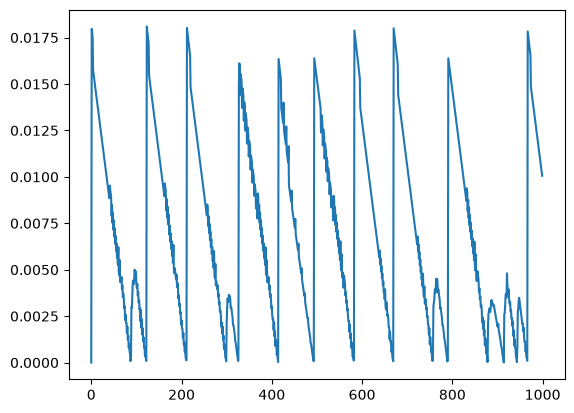

In [33]:
# =======================================
# MODULE 3 : MODEL TRAINING AND EVALUATION
# =======================================

def perceptron(X, y, learning_rate=0.01, epochs=1000, tol =1e-10):
    
    #Dimension of Design matrix
    M, N = X.shape
    #loss history 
    hist = []
    global_loss = []
    
    # Initialize weights to zero
    w = np.zeros(N)
    lr = learning_rate
    
    #for tolerance
    prev_loss = np.inf
    threshold = 10 # threshold if loss is same for 10 iteration model will stop training 
    no_change_count = 0
    


    for epoch in range(1, epochs+1):
        
        # Forward pass : computing the functional scores for all M samples 
        z = np.dot(X, w)
        
        
        # Defining the Active Error Mask (Identify where the prediction is wrong i.e -ve answer)
        misclassified = (y * z) <= 0 # Boolean array of shape : (M,)
        num_error = np.sum(misclassified) # Total misclassified points (TRUE -> 1 , FALSE -> 0)
        hist.append(num_error)
        
        # Calculating the global loss ---
        
        #loss = -np.sum(z[misclassified]) if num_error > 0 else 0.0
        each_losses = np.maximum(0, -y[misclassified] * z[misclassified])
        loss = np.mean(each_losses)
        global_loss.append(loss)
        
        
        # Termination Criteria Check
        if num_error == 0:
            print(f"Convergence Achieved at epoch :{epoch}")
            print(f"Final Parameters vector : {w}")
            
            break 
        
        if (prev_loss - loss) < tol:
            no_change_count +=1
        else:
            no_change_count = 0
        prev_loss = loss
        
        if no_change_count >= threshold:
            print("--- THE DATA IS NON-LINEAR ---- ")
            print(f"Training Stopped at epoch : {epoch} | loss plateaued tolerance : {tol} | loss : {loss} | no_change_count : {no_change_count}")
            break        
        
        # Matrix Sub-gradient Update 
        # Isolating active errors 
        y_errors = y[misclassified] #shape:(nun_error,)
        X_errors = X[misclassified] #shape:(num_error, 3)
        
        # Calculating the complete gradient 
        dl = (X_errors.T @ y_errors) # shape : (3,1)
        
        
        # Updating the weight parameters 
        w += (lr/M) * dl

        if epoch % 200 ==0 or epoch == 1 :
            print(f"Epoch {epoch:02d} | Active Errors Count: {num_error:02d} | loss : {loss} | no_change_count : {no_change_count}")

    return w, hist,global_loss



# Shuffle the training data before each epoch to ensure randomness
perm = np.random.permutation(len(X_train))
X_train = X_train[perm]
y_train = y_train[perm]


# Making a Design matrix (adding bias)
X_design = np.c_[np.ones(X_train.shape[0]), X_train]


# Learning rate 
lr = 0.01
epochs = 1000

w, hist,global_loss = perceptron(X_design, y_train, learning_rate=lr, epochs=epochs)
print("----"*20)
print(f"Final Parameters vector : {w}")
plt.plot(global_loss)
plt.show()


## The Perceptron Convergence Theorem

### Structural Framing & Core Axioms

The theorem states: **if the data are linearly separable, the perceptron will converge to a perfect separating hyperplane in a finite number of updates**.

Assume:

- Bias is absorbed into $\mathbf{w}$ and $\mathbf{x}$.
- Initial weights are zero: $\mathbf{w}^{(0)} = \mathbf{0}$.
- Let $\mathbf{w}^{(k)}$ be the weight vector after $k$ mistakes. For each mistake (with $\eta = 1$):

$$
\mathbf{w}^{(k+1)} = \mathbf{w}^{(k)} + y^{(k)}\mathbf{x}^{(k)}
$$

---

### Definition of Geometric Invariant Bounds

Because the data are linearly separable, two constants exist:

1. **Separation Margin $\gamma$** – there exists a unit vector $\mathbf{w}^*$ ($\|\mathbf{w}^*\| = 1$) that correctly classifies all points with a margin:

$$
y^{(i)} (\mathbf{w}^{*T} \mathbf{x}^{(i)}) \ge \gamma > 0 \quad \forall i
$$

2. **Data Radius Bound $R$** – all inputs lie within a sphere of radius $R$:

$$
\|\mathbf{x}^{(i)}\|^2 \le R^2 \quad \forall i
$$

---

### Derivation of the Lower Bound

We track the projection of $\mathbf{w}^{(k)}$ onto the optimal direction $\mathbf{w}^*$:

$$
\mathbf{w}^{*T} \mathbf{w}^{(k+1)} = \mathbf{w}^{*T} \mathbf{w}^{(k)} + y^{(k)} (\mathbf{w}^{*T} \mathbf{x}^{(k)}) \ge \mathbf{w}^{*T} \mathbf{w}^{(k)} + \gamma
$$

Starting from $\mathbf{w}^{(0)} = \mathbf{0}$, after $k$ updates:

$$
\mathbf{w}^{*T} \mathbf{w}^{(k)} \ge k\gamma
$$

By Cauchy‑Schwarz and $\|\mathbf{w}^*\| = 1$:

$$
k\gamma \le \mathbf{w}^{*T} \mathbf{w}^{(k)} \le \|\mathbf{w}^{(k)}\|
$$

Squaring gives the **lower bound**:

$$
\|\mathbf{w}^{(k)}\|^2 \ge k^2 \gamma^2 \tag{4.1}
$$

---

### Derivation of the Upper Bound

Compute the squared norm after an update:

$$
\|\mathbf{w}^{(k+1)}\|^2 = \|\mathbf{w}^{(k)} + y^{(k)}\mathbf{x}^{(k)}\|^2
= \|\mathbf{w}^{(k)}\|^2 + 2y^{(k)}(\mathbf{w}^{(k)T}\mathbf{x}^{(k)}) + \|\mathbf{x}^{(k)}\|^2
$$

Since an update happens only when the point is misclassified, $y^{(k)}(\mathbf{w}^{(k)T}\mathbf{x}^{(k)}) \le 0$, so the middle term is non‑positive. Also, $\|\mathbf{x}^{(k)}\|^2 \le R^2$. Thus:

$$
\|\mathbf{w}^{(k+1)}\|^2 \le \|\mathbf{w}^{(k)}\|^2 + R^2
$$

With $\|\mathbf{w}^{(0)}\|^2 = 0$, after $k$ updates:

$$
\|\mathbf{w}^{(k)}\|^2 \le k R^2 \tag{4.2}
$$

---

### The Inequality Sandwich Resolution

Combining (4.1) and (4.2):

$$
k^2 \gamma^2 \le \|\mathbf{w}^{(k)}\|^2 \le k R^2
$$

Hence:

$$
k^2 \gamma^2 \le k R^2 \quad \Longrightarrow \quad k \le \left( \frac{R}{\gamma} \right)^2
$$

**Key takeaways:**

- **Margin $\gamma$** – a small margin increases the maximum number of mistakes.
- **Data radius $R$** – larger spread requires more updates.
- **Dimensionality $N$ does not appear** – convergence depends only on the geometric separation, not on the number of features.

---



In [51]:
# ==========================================
# MODULE 4 : PERCEPTRON CONVERGENCE THEOREM
# ==========================================


def perceptron_convergence_theorem(X, y, w):
    """
    Computes the theoretical bounds of the Perceptron Convergence Theorem.
    
    Parameters:
    - X: Design matrix (with bias term)
    - y: Labels
    - w: Learned weight vector
    
    Returns:
    - R: Radius bound
    - gamma: Minimum margin
    - K: Theoretical mistake bound
    """
    # Radius bound 
    R = np.max(np.linalg.norm(X, axis=1))

    # Normalize the final weight vector
    w_norm = w / np.linalg.norm(w)

    # Compute signed margins for all training points
    margins = y * np.dot(X, w_norm)

    # Minimum margin (should be > 0 if all points are correctly classified)
    gamma = np.min(margins)

    # Theoretical mistake bound
    K = (R / gamma) ** 2 if gamma > 0 else float('inf')

    return R, gamma, K, margins


R, gamma, K, margins = perceptron_convergence_theorem(X_design, y_train, w)


print("\n--- THEORETICAL BOUNDS (using learned weights) ---")
print(f"Data Radius Bound (R): {R:.4f}")
print(f"Minimum Margin (gamma): {gamma:.4f}")
print(f"Theoretical Max Mistake Allowed (K Limit): {K:.4f}")

# Optional: verify all margins are positive
if np.all(margins > 0):
    print("All margins are positive – classification is correct.")
else:
    print("WARNING: Some margins are <= 0 – training did not converge perfectly (May contain Noise).")


#NOTE: For Perceptron Theorem to converge data must be linear (Should Contain no Noise)
#NOTE: 'flip_y' adds noise in data. Put flip_y=0 for perfectly linear data 


--- THEORETICAL BOUNDS (using learned weights) ---
Data Radius Bound (R): 3.8833
Minimum Margin (gamma): -2.2484
Theoretical Max Mistake Allowed (K Limit): inf




## Loss Function Optimization & Subgradient Calculus

### Non‑Differentiability & The Failure of Calculus Optimisation

Modern deep learning relies on **gradient descent**, which requires smooth derivatives. The perceptron’s step activation function is problematic:

$$
f(z) =
\begin{cases}
+1 & \text{if } z \ge 0 \\[4pt]
-1 & \text{if } z < 0
\end{cases}
$$

- Everywhere except $z=0$, the derivative is **zero** – no gradient information.
- At $z=0$, the derivative is **undefined** (infinite discontinuity).

To overcome this, we optimise a continuous surrogate loss function instead of the step output itself.

---

### Continuous Surrogate Loss Functions

| Loss Function       | Mathematical Formulation                     | Characteristics |
|---------------------|----------------------------------------------|-----------------|
| **0‑1 Loss**        | $\mathcal{L} = \mathbb{I}(y \cdot z < 0)$   | Flat; gradient zero everywhere – unusable. |
| **Perceptron Loss** | $\mathcal{L} = \max(0, -y \cdot z)$         | Piecewise linear; penalises errors by distance. |
| **Hinge Loss**      | $\mathcal{L} = \max(0, 1 - y \cdot z)$      | SVM uses this; introduces a safety margin of 1. |
| **Logistic Loss**   | $\mathcal{L} = \log(1 + \exp(-y \cdot z))$  | Smooth and differentiable; yields probabilistic outputs. |

---

### Derivation of the Perceptron Loss Function

We want a loss that is **zero for correct predictions** and **linear for misclassifications**.

#### Step 1 – Signed Margin Distance

The quantity $y^{(i)}(\mathbf{w}^T\mathbf{x}^{(i)})$ indicates correctness:

- Correct: same sign → product $\ge 0$.
- Misclassified: opposite signs → product $< 0$.

#### Step 2 – Piecewise Maximum Operator

Define:

$$
\mathcal{L}(\mathbf{w}) = \max\left(0, \, -y^{(i)}(\mathbf{w}^T\mathbf{x}^{(i)})\right)
$$

- Correct: $\max(0, \text{negative}) = 0$.
- Wrong: $\max(0, \text{positive}) = -y^{(i)}(\mathbf{w}^T\mathbf{x}^{(i)})$, which grows linearly with the degree of misclassification.

---

### Subgradient Derivation & The Unified Update Rule

The Perceptron loss has a sharp “kink” at zero, so we use **subgradients**.

- **Correct** ($y^{(i)}(\mathbf{w}^T\mathbf{x}^{(i)}) \ge 0$):  
  $\nabla_{\mathbf{w}} \mathcal{L} = \mathbf{0}$

- **Misclassified** ($y^{(i)}(\mathbf{w}^T\mathbf{x}^{(i)}) < 0$):  
  $\nabla_{\mathbf{w}} \mathcal{L} = -y^{(i)} \mathbf{x}^{(i)}$

Thus:

$$
\nabla_{\mathbf{w}} \mathcal{L}(\mathbf{w}) =
\begin{cases}
\mathbf{0} & \text{if } y^{(i)}(\mathbf{w}^T\mathbf{x}^{(i)}) \ge 0 \\[6pt]
-y^{(i)} \mathbf{x}^{(i)} & \text{if } y^{(i)}(\mathbf{w}^T\mathbf{x}^{(i)}) < 0
\end{cases}
$$

Plugging this into the standard gradient descent update $\mathbf{w}_{\text{new}} = \mathbf{w}_{\text{old}} - \eta \nabla_{\mathbf{w}} \mathcal{L}$ gives:

$$
\mathbf{w}_{\text{new}} = \mathbf{w}_{\text{old}} - \eta \bigl(-y^{(i)}\mathbf{x}^{(i)}\bigr) = \mathbf{w}_{\text{old}} + \eta \, y^{(i)}\mathbf{x}^{(i)}
$$

This proves that **Rosenblatt’s original error‑correction rule** is exactly **Stochastic Gradient Descent** on the continuous Perceptron loss.

---


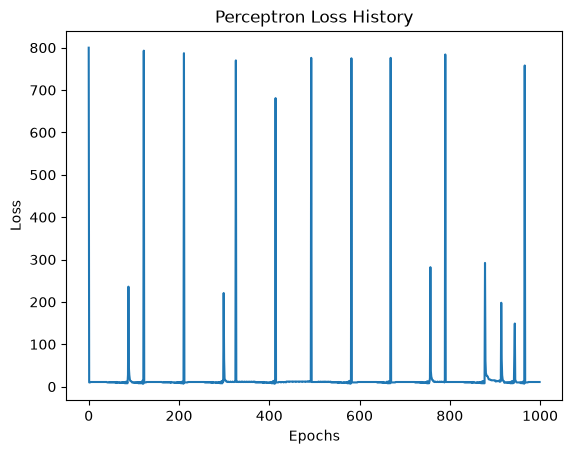

In [ ]:
# =========================================
# MODULE 5 : PREDICTION AND EVALUATION
# =========================================

def predict(X, w):
    """ Set Activation function : sign(W^T X) -- vectorized over all rows """
    # z score
    z = X @ w
    return np.where(z >= 0, 1, -1)


# Making a Design matrix (adding bias) for test set
X_test_design = np.c_[np.ones(X_test.shape[0]), X_test]

# Predicting the test set labels and calculating the accuracy
y_pred = predict(X_test_design, w)
accuracy = np.mean(y_pred == y_test)



# plotting the error history
plt.plot(hist)
plt.title('Perceptron Loss History')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show() 

In [ ]:
# ========================================= 
# MODULE 6 : MODEL COMPARISON WITH SKLEARN
# =========================================     


# comparing from Sklearn
from sklearn.linear_model import Perceptron

# Initializing the perceptron
clf = Perceptron(max_iter=1000, tol=1e-3, random_state=42, eta0=0.01)

# Train the Model
clf.fit(X_train, y_train)

#Evaluate the model
accuracy_skl = clf.score(X_test, y_test)


print(f"Sklearn Accuracy : {accuracy_skl*100:.2f}%")
print(f"Model Accuracy : {accuracy*100:.2f}%")



Sklearn Accuracy : 99.50%
Model Accuracy : 99.50%


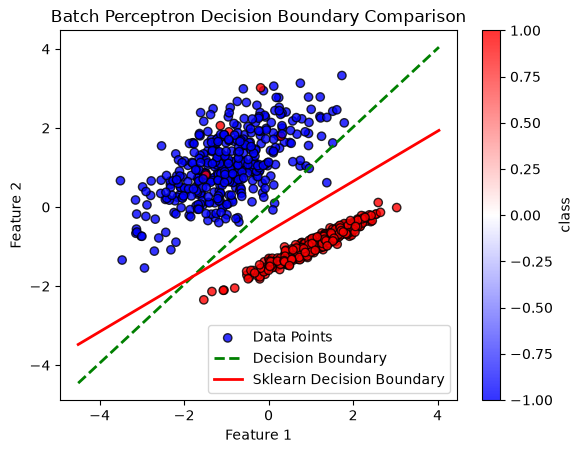

In [ ]:
# ==============================================
# MODULE 7 : VISUALIZATION OF DECISION BOUNDARY
# ==============================================

def plot_twoD_decision_boundary(X, y, w, clf=None):
    
    
    # Create a grid of points to plot the decision boundary
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    # Create a grid of points to plot the decision boundary
    x_values = np.linspace(x_min, x_max, 100)
    y_values = np.linspace(y_min, y_max, 100)
    
    # Calculate the corresponding y values for the decision boundary
    decision_boundary = -(w[0] + w[1] * x_values) / w[2]  
    
    
    # Plot the decision boundary and the training points
    plt.scatter(X[:, 0], X[:, 1], c=y,edgecolors='k', cmap='bwr', alpha=0.8, label='Data Points')
    plt.plot(x_values, decision_boundary,'--', color='green', linewidth=2, label='Decision Boundary')
    
    # NEW: Plot the scikit-learn decision boundary if provided
    if clf is not None:
        w_sk = clf.coef_[0]
        b_sk = clf.intercept_[0]
        # Equation: b_sk + w_sk[0]*x + w_sk[1]*y = 0  -> y = -(b_sk + w_sk[0]*x) / w_sk[1]
        sk_decision_boundary = -(b_sk + w_sk[0] * x_values) / w_sk[1]
        plt.plot(x_values, sk_decision_boundary, '-', color='red', linewidth=2, label='Sklearn Decision Boundary')

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Batch Perceptron Decision Boundary Comparison')
    plt.colorbar(label='class')
    plt.legend()
    plt.show()

# Plotting the decision boundary for 3D data
def plot_threeD_decision_boundary(X, y, w, clf=None):
    from mpl_toolkits.mplot3d import Axes3D
    
    # Create a grid of points to plot the decision boundary
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1.5
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1.5
    
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))
    
    # Calculate the corresponding z values for your custom decision boundary plane
    zz = (-w[0] - w[1] * xx - w[2] * yy) / w[3]
    
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot your custom decision boundary surface
    ax.plot_surface(xx, yy, zz, alpha=0.3, color='green', label='Custom Boundary')
    
    # NEW: Plot the scikit-learn decision boundary surface if provided
    if clf is not None:
        w_sk = clf.coef_[0]
        b_sk = clf.intercept_[0]
        # Equation: b_sk + w_sk[0]*x + w_sk[1]*y + w_sk[2]*z = 0 -> z = (-b_sk - w_sk[0]*x - w_sk[1]*y) / w_sk[2]
        zz_sk = (-b_sk - w_sk[0] * xx - w_sk[1] * yy) / w_sk[2]
        ax.plot_surface(xx, yy, zz_sk, alpha=0.3, color='red', label='Sklearn Boundary')

    # Plot training points
    ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, edgecolors='k', cmap='bwr', alpha=0.6, label='Training Points')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_zlabel('Feature 3')
    plt.title('Batch Perceptron Decision Boundary Comparison')
    plt.show()    
    
if X_train.shape[1] == 2:
    plot_twoD_decision_boundary(X_train, y_train, w, clf=clf)   
elif X_train.shape[1] == 3:
    plot_threeD_decision_boundary(X_train, y_train, w, clf=clf)
else:
    print("The dataset has more than 3 features. Use dimensionality reduction techniques to visualize the decision boundary.")        




## Structural Limitations and the XOR Failure Mode

A single‑layer perceptron **cannot** compute curved, twisted, or non‑linear decision boundaries.

#### The Canonical Counter‑Example: XOR (Exclusive OR)

This limitation was mathematically proven by **Minsky & Papert (1969)** using the logical XOR truth table:

| $x_1$ | $x_2$ | Target $y$ | Coordinate |
|:-----:|:-----:|:----------:|:----------:|
| 0     | 0     | -1         | (0,0)      |
| 1     | 0     | +1         | (1,0)      |
| 0     | 1     | +1         | (0,1)      |
| 1     | 1     | -1         | (1,1)      |

#### Algebraic Impossibility Proof

Assume a valid line exists, i.e., there are real numbers $w_1, w_2, b$ satisfying all four conditions:

1. For $(0,0)$: $\;b < 0$
2. For $(1,0)$: $\;w_1 + b \ge 0$
3. For $(0,1)$: $\;w_2 + b \ge 0$
4. For $(1,1)$: $\;w_1 + w_2 + b < 0$

Adding inequalities (2) and (3):

$$
(w_1 + b) + (w_2 + b) \ge 0 \implies w_1 + w_2 + 2b \ge 0
$$

Rewrite as:

$$
(w_1 + w_2 + b) + b \ge 0
$$

But from (4), $(w_1 + w_2 + b) < 0$, and from (1), $b < 0$.  
The sum of two negative numbers is negative, contradicting the conclusion that it is $\ge 0$.  
Hence, **no linear classifier can solve XOR** – a single perceptron is structurally incapable of handling non‑linear patterns.



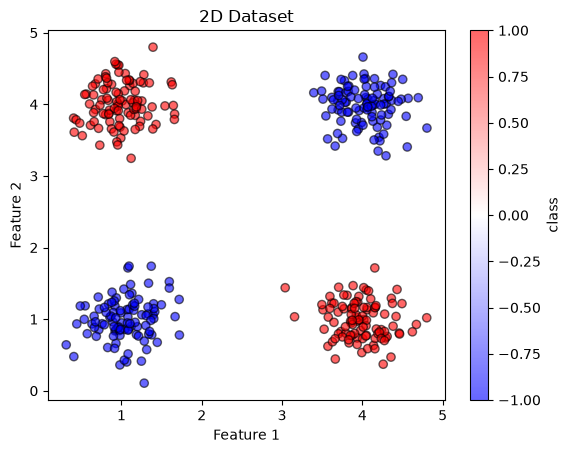

In [ ]:
# ================================================= 
# MODULE 8 : LIMITATIONS OF PERCEPTRON(XOR PROBLEM)
# ================================================= 



np.random.seed(10)
X_class_neg_1 = np.random.randn(100, 2) * 0.3 + np.array([1.0, 1.0])
y_class_neg_1 = -np.ones(100)

X_class_neg_2 = np.random.randn(100, 2) * 0.3 + np.array([4.0, 4.0])
y_class_neg_2 = -np.ones(100)



X_class_pos_1 = np.random.randn(100, 2) * 0.3 + np.array([4.0, 1.0])
y_class_pos_1 = np.ones(100)

X_class_pos_2 = np.random.randn(100, 2) * 0.3 + np.array([1.0, 4.0])
y_class_pos_2 = np.ones(100)


X_train_ = np.vstack([X_class_neg_1, X_class_neg_2, X_class_pos_1, X_class_pos_2])
y_train_ = np.concatenate([y_class_neg_1, y_class_neg_2, y_class_pos_1, y_class_pos_2])
    
twoD_plot_dataset(X_train_, y_train_)

Epoch 01 | Active Errors Count: 400 | loss : 0.0 | no_change_count : 0
--- THE DATA IS NON-LINEAR ---- 
Training Stopped at epoch : 11 | loss plateaued tolerance : 0.1 | loss : 0.06399545324477383 | no_change_count : 10
Final Parameters vector : [0.00495    0.01103365 0.01245478]
Maximum Loss :  0.06647253972586539


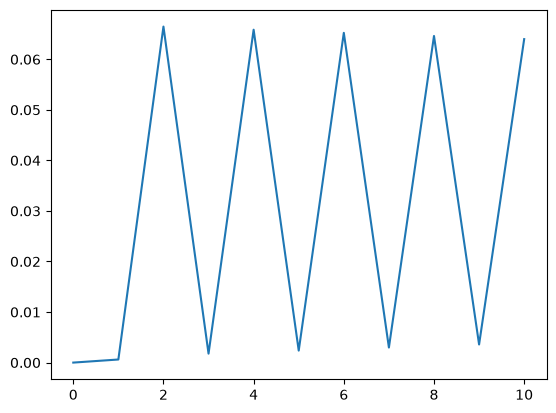

In [47]:
# Making a Design matrix (adding bias)
X_design_ = np.c_[np.ones(X_train_.shape[0]), X_train_]

# Learning rate & Epochs 
lr = 0.01
epochs = 1000

w_xor, hist_xor, global_loss = perceptron(X_design_, y_train_, learning_rate=lr, epochs=epochs, tol=1e-1)

print(f"Final Parameters vector : {w_xor}")
print("Maximum Loss : ",np.max(global_loss))
plt.plot(global_loss)
plt.show()

In [48]:
# Perceptron Convergence Bound

R, gamma, K, margins = perceptron_convergence_theorem(X_design_, y_train_, w_xor)


print("\n--- THEORETICAL BOUNDS (using learned weights) ---")
print(f"Data Radius Bound (R): {R:.4f}")
print(f"Minimum Margin (gamma): {gamma:.4f}")
print(f"Theoretical Max Mistake Allowed (K Limit): {K:.4f}")

# Optional: verify all margins are positive
if np.all(margins > 0):
    print("All margins are positive – classification is correct.")
else:
    print("WARNING: Some margins are <= 0 – training did not converge perfectly.(Data is Non-linear)")


--- THEORETICAL BOUNDS (using learned weights) ---
Data Radius Bound (R): 6.3392
Minimum Margin (gamma): -6.2669
Theoretical Max Mistake Allowed (K Limit): inf


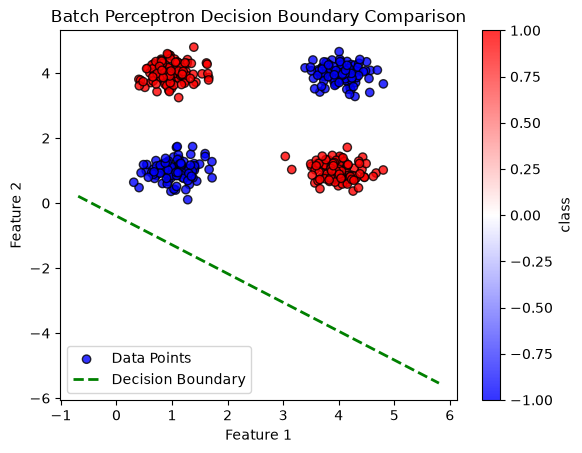

In [49]:
# Decision boundary 
plot_twoD_decision_boundary(X_train_, y_train_, w_xor)


## Architectural Engineering Constraints

Despite its elegance, the single‑layer perceptron has critical limitations:

#### 1. Inability to Handle Overlapping Classes

If the data are **not linearly separable** ($\gamma \le 0$), the convergence bound becomes infinite. The algorithm will oscillate forever. In practice, we must impose a **maximum epoch** limit.

#### 2. Lack of Probabilistic Calibration

The step function outputs only hard decisions ($\pm 1$). There is **no confidence score** – points near the boundary receive the same classification as points deep inside a cluster.

#### 3. Suboptimal Generalisation

The perceptron stops as soon as **one** separating line is found – it does not maximise the margin. Consequently, the resulting boundary often lies close to the data, making it sensitive to noise and prone to overfitting. **Support Vector Machines (SVMs)** improve upon this by maximising the margin.